# Clasificacion de Imagenes con Redes Neuronales: MNIST

En este notebook aplicaremos lo aprendido en clasificacion a un problema real: reconocer digitos escritos a mano.

El dataset **MNIST** contiene 70,000 imagenes de digitos (0-9) de 28x28 pixeles.

## Paso 1: Cargar y Preparar los Datos

Cada imagen es de 28x28 = 784 pixeles. Para la red neuronal, "aplanamos" la imagen en un vector de 784 valores.

In [4]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos MNIST
(X_train_img, y_train), (X_test_img, y_test) = keras.datasets.mnist.load_data()

# Normalizar pixeles de [0, 255] a [0, 1]
X_train_img = X_train_img.astype('float32') / 255.0
X_test_img = X_test_img.astype('float32') / 255.0

# Aplanar imagenes de 28x28 a vector de 784
X_train = X_train_img.reshape(-1, 784)
X_test = X_test_img.reshape(-1, 784)

print(f"Imagenes de entrenamiento: {X_train.shape}")
print(f"Imagenes de prueba: {X_test.shape}")
print(f"Clases: {np.unique(y_train)}")

Imagenes de entrenamiento: (60000, 784)
Imagenes de prueba: (10000, 784)
Clases: [0 1 2 3 4 5 6 7 8 9]


## Visualizar Ejemplos

Veamos como se ven los digitos del dataset:

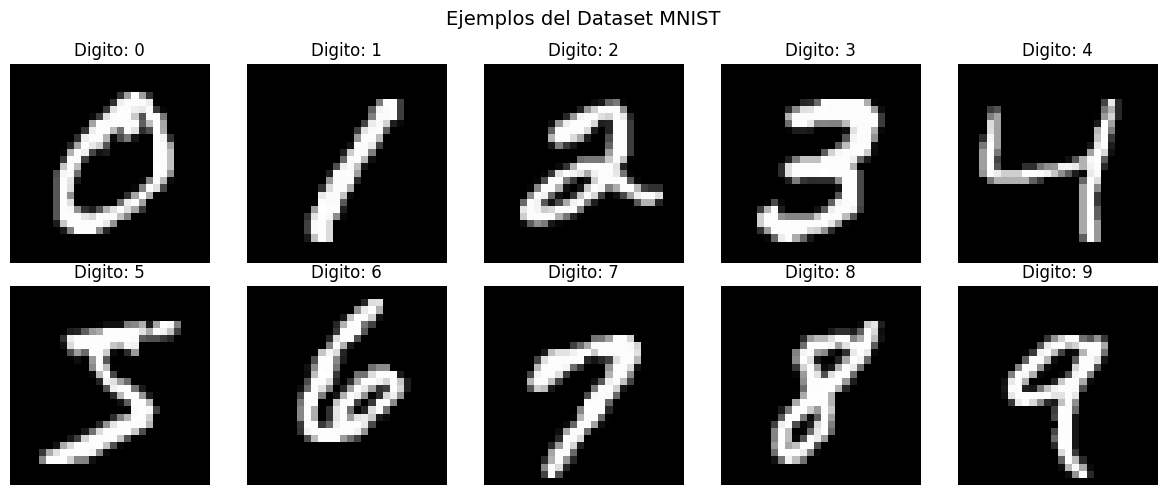

In [5]:
# Mostrar un ejemplo de cada digito
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    row, col = digit // 5, digit % 5
    axes[row, col].imshow(X_train_img[idx], cmap='gray')
    axes[row, col].set_title(f'Digito: {digit}')
    axes[row, col].axis('off')

plt.suptitle('Ejemplos del Dataset MNIST', fontsize=14)
plt.tight_layout()
plt.show()

## modelo_1: Sin funciones de activacion

Igual que en el notebook de clasificacion, empezamos con un modelo **sin funciones de activacion** en las capas ocultas para ver que pasa.

In [6]:
modelo_1 = keras.Sequential([
    keras.layers.Dense(128, input_shape=(784,)),  # Sin activacion
    keras.layers.Dense(64),                        # Sin activacion
    keras.layers.Dense(10, activation='softmax')   # Softmax para clasificacion
])

modelo_1.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historial_1 = modelo_1.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), verbose=1)

/Users/emiliosandoval/anaconda3/envs/ibero-nov-2025-05/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-24 00:51:00.440898: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-01-24 00:51:00.445589: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-24 00:51:00.445661: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-01-24 00:51:00.446312: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-01-24 00:51:00.446345: I tensorflow/core/common_runtime/pluggable_device/pluggabl

Epoch 1/10


2026-01-24 00:51:01.936861: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8571 - loss: 0.5134 - val_accuracy: 0.9053 - val_loss: 0.3368
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9061 - loss: 0.3301 - val_accuracy: 0.9146 - val_loss: 0.3055
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9132 - loss: 0.3072 - val_accuracy: 0.9158 - val_loss: 0.2979
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9159 - loss: 0.2955 - val_accuracy: 0.9184 - val_loss: 0.2918
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9185 - loss: 0.2883 - val_accuracy: 0.9217 - val_loss: 0.2827
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9203 - loss: 0.2828 - val_accuracy: 0.9224 - val_loss: 0.2842
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 96s 51ms/step - accuracy: 0.9219 - loss: 0.2787 - val_accuracy: 0.9211 - val_loss: 0.2800
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9219 - loss: 0.27

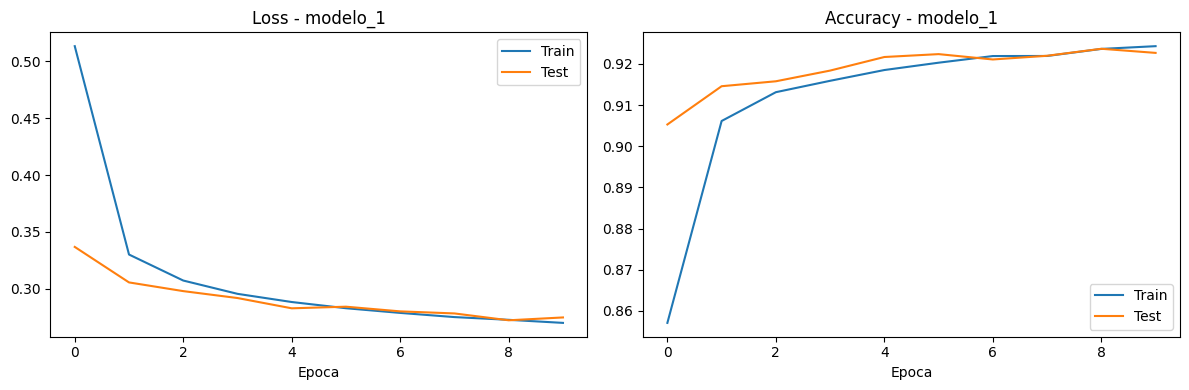

Accuracy final (test): 0.9227


In [7]:
# Visualizar entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historial_1.history['loss'], label='Train')
axes[0].plot(historial_1.history['val_loss'], label='Test')
axes[0].set_title('Loss - modelo_1')
axes[0].set_xlabel('Epoca')
axes[0].legend()

axes[1].plot(historial_1.history['accuracy'], label='Train')
axes[1].plot(historial_1.history['val_accuracy'], label='Test')
axes[1].set_title('Accuracy - modelo_1')
axes[1].set_xlabel('Epoca')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Accuracy final (test): {historial_1.history['val_accuracy'][-1]:.4f}")


## modelo_2: Con funciones de activacion (ReLU)

Ahora agregamos **ReLU** en las capas ocultas para introducir no-linealidad:

In [8]:
modelo_2 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

modelo_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historial_2 = modelo_2.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), verbose=1)

Epoch 1/10
 660/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.7948 - loss: 0.6831

: 

In [ ]:
# Visualizar entrenamiento modelo_2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historial_2.history['loss'], label='Train')
axes[0].plot(historial_2.history['val_loss'], label='Test')
axes[0].set_title('Loss - modelo_2')
axes[0].set_xlabel('Epoca')
axes[0].legend()

axes[1].plot(historial_2.history['accuracy'], label='Train')
axes[1].plot(historial_2.history['val_accuracy'], label='Test')
axes[1].set_title('Accuracy - modelo_2')
axes[1].set_xlabel('Epoca')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Accuracy final (test): {historial_2.history['val_accuracy'][-1]:.4f}")

## Comparacion de Modelos

In [ ]:
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['modelo_1 (sin activacion)', 'modelo_2 (ReLU + Adam)'],
    'Accuracy Train': [
        historial_1.history['accuracy'][-1],
        historial_2.history['accuracy'][-1]
    ],
    'Accuracy Test': [
        historial_1.history['val_accuracy'][-1],
        historial_2.history['val_accuracy'][-1]
    ]
})

resultados

## Visualizar Predicciones

Veamos como el mejor modelo predice algunos digitos:

In [ ]:
# Seleccionar 8 imagenes aleatorias del set de prueba
indices_aleatorios = np.random.choice(len(X_test), 8, replace=False)

# Predecir
predicciones = modelo_2.predict(X_test[indices_aleatorios], verbose=0)
predicciones_clase = np.argmax(predicciones, axis=1)

# Mostrar en cuadricula 2x4
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, idx in enumerate(indices_aleatorios):
    row, col = i // 4, i % 4
    axes[row, col].imshow(X_test_img[idx], cmap='gray')
    
    real = y_test[idx]
    pred = predicciones_clase[i]
    color = 'green' if pred == real else 'red'
    axes[row, col].set_title(f'Real: {real} | Pred: {pred}', color=color, fontsize=11)
    axes[row, col].axis('off')

plt.suptitle('Predicciones en imagenes aleatorias (verde=correcto, rojo=error)', fontsize=12)
plt.tight_layout()
plt.show()